In this notebook, 

# step 1 preprocessing

The image processing step (input: raw images, output: fitted bright spots) can be found in github::ecDNATracer (add link).

Once we have fitted the fitted bright spots, we use that as input to the ecDNATracer, which outputs assembled ecDNA/chr7_endogenous traces. An example can be found in github::ecDNATracer (add link.)

# Computing median distance matrix

For this script, we will start from the median distance matrix. 

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import sys

In [14]:
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_HelperFunctions import *
from plot import *

## load traces

In [5]:
import pickle
with open(r'D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___invitro_03012025\BT__preEM_strict_redooffby1_31FOVs__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)
tr_type = 'Xtraces_chrom_inter_73_253_254'
linear_traces, circ_traces = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces.shape

((849, 252, 6), (35969, 252, 6))

## compute median distance matrix

In [6]:
linear_meddist = np.nanmedian(compute_med_dist_mat(linear_traces, contact_dist = None), axis = 0)
circ_meddist = np.nanmedian(compute_med_dist_mat(circ_traces, contact_dist = None), axis = 0)

100%|██████████████████████████████████████████████████████████████████████████| 35969/35969 [00:09<00:00, 3666.55it/s]


## plot median distance matrix

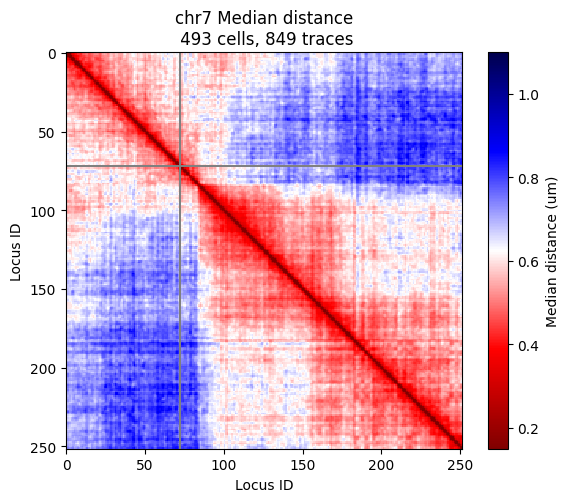

In [7]:
## chr7
ntrs = len(linear_traces)
ncells = len(np.unique(np.nanmean(linear_traces[:,:,-1], axis = 1)))

# --- Data & colormap with NaNs as dark gray ---
M0 = linear_meddist.copy()
M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.15, vmax=1.1,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (um)')

ax.set_title(f'chr7 Median distance\n {ncells} cells, {ntrs} traces')

fig.tight_layout()

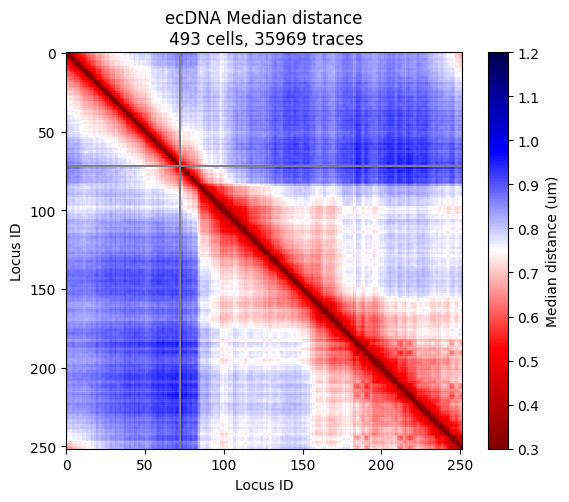

In [10]:
## ecDNA
ntrs = len(circ_traces)
ncells = len(np.unique(np.nanmean(circ_traces[:,:,-1], axis = 1)))

# --- Data & colormap with NaNs as dark gray ---
M0 = circ_meddist.copy()
M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.3, vmax=1.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (um)')
ax.set_title(f'ecDNA Median distance\n {ncells} cells, {ntrs} traces')

fig.tight_layout()

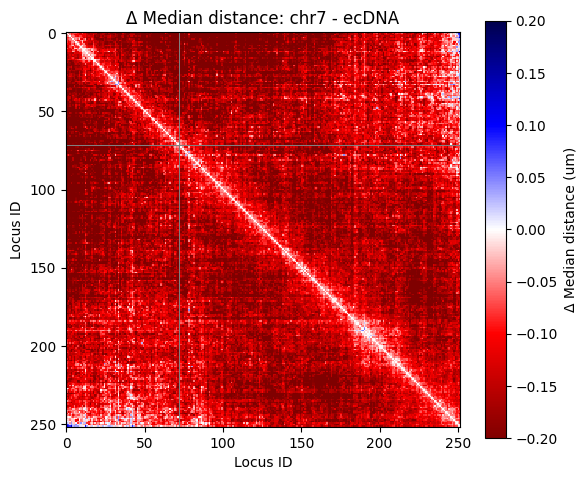

In [11]:
## difference matrix
# --- Data & colormap with NaNs as dark gray ---
Mdiff = linear_meddist - circ_meddist
M0 = cv2.blur(Mdiff, (2,2))
Mdiff[72, :] = np.NaN
Mdiff[:, 72] = np.NaN
cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(Mdiff, cmap=cmap, vmin=-0.2, vmax=0.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Median distance (um)')

ax.set_title(f'Δ Median distance: chr7 - ecDNA')

fig.tight_layout()

# radius of gyration

In [12]:
def get_rgs(coords_um):
    coords_um = np.array(coords_um)
    coords_um -= np.nanmean(coords_um, axis=0)[np.newaxis, :]  # center of mass
    distances = np.linalg.norm(coords_um, axis=-1)
    rg = np.sqrt(np.nanmean(distances ** 2))
    return rg

In [13]:
circ_all_rgs = [get_rgs(tr[:,:3]) for tr in circ_traces]
lin_all_rgs = [get_rgs(tr[:,:3]) for tr in linear_traces]

In [15]:
df_plot_violin = pd.DataFrame(lin_all_rgs+ circ_all_rgs, columns = ['rgs'])
df_plot_violin['is_circular'] = [0] * len(lin_all_rgs) + [1] * len(circ_all_rgs)
df_plot_violin

,rgs,is_circular
0,0.655719,0
1,0.518836,0
2,0.585255,0
3,0.533491,0
4,0.612887,0
...,...,...
36813,0.652002,1
36814,1.272979,1
36815,1.265202,1
36816,0.471146,1


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Radius of gyration:\nchr7 vs. ecDNA'}, ylabel='Radius of gyration (µm)'>,
             rgs  is_circular
 0      0.655719        False
 1      0.518836        False
 2      0.585255        False
 3      0.533491        False
 4      0.612887        False
 ...         ...          ...
 36813  0.652002         True
 36814  1.272979         True
 36815  1.265202         True
 36816  0.471146         True
 36817  0.534194         True
 
 [36818 rows x 2 columns],
 {'U': 9565534.0, 'p': 8.812756476219886e-78, 'q': None})

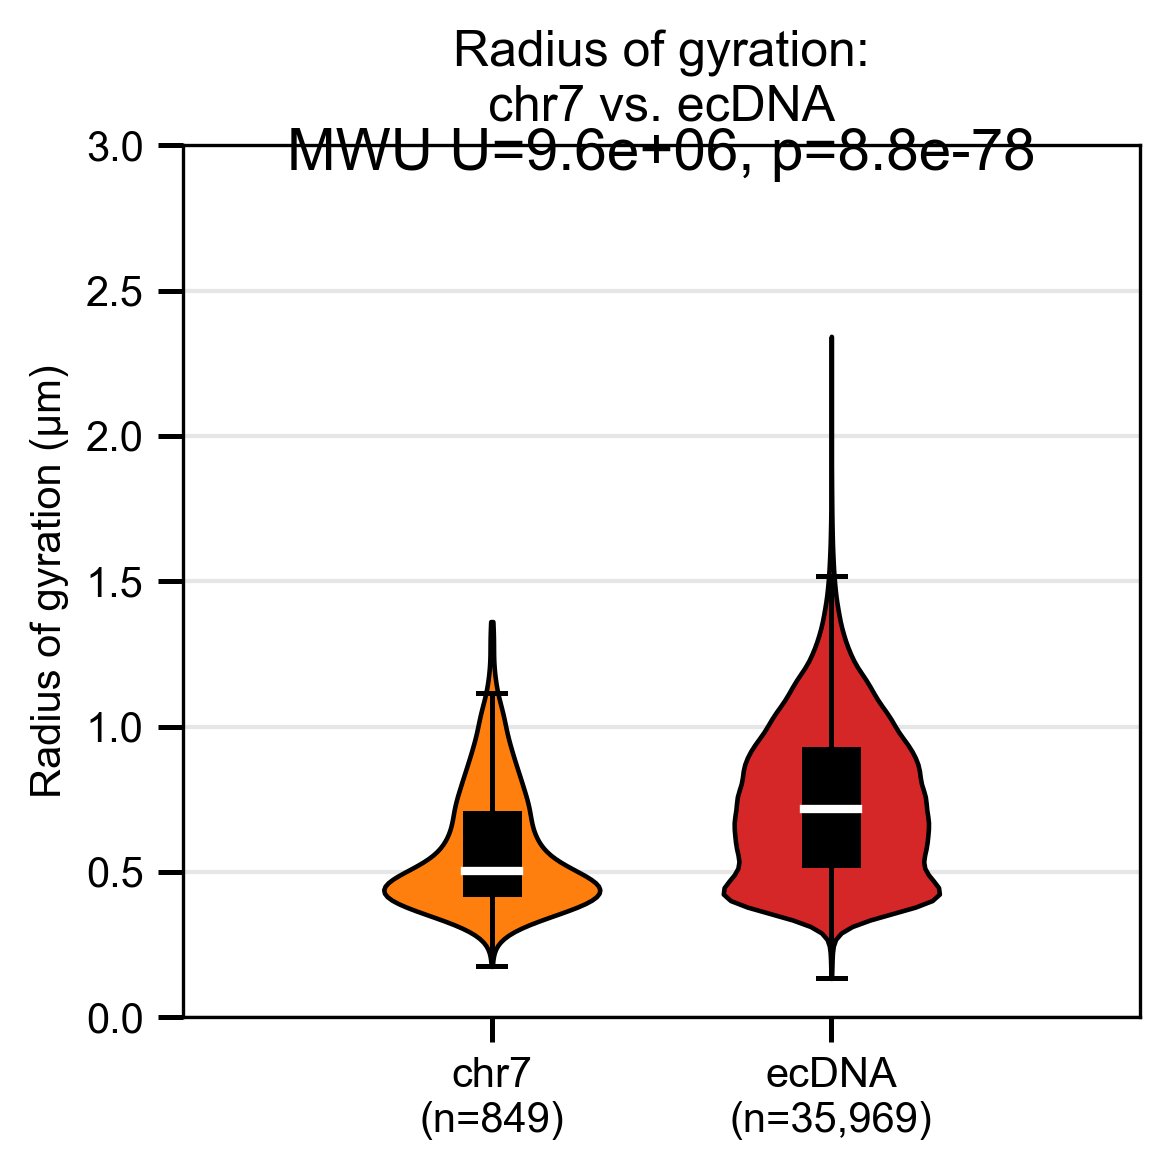

In [16]:
violin_two_groups_by_bool_mean_matplotlib(
    df=df_plot_violin,
    val_col='rgs',
    bool_col="is_circular",  # your boolean column
    order = (False, True),
    group_labels={True: "ecDNA", False: "chr7"},
    colors=("C1", "C3"),
    title="Radius of gyration:\nchr7 vs. ecDNA",
    y_label='Radius of gyration (µm)',
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative="less", # "two-sided", "less"
    y_tick_step= 0.5,
    stats_fontsize=14,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=2,
    # save_svg = r'C:/GBM39/manuscript_figures/invitro_fig1/plots/rgs/BT_chr7_vs_ecDNA_rgs_V3_MWU.svg',
)